In [2]:
# ============================================
# MILESTONE: This is to combine all the work 
# from the previous weeks into a single notebook.
# The goal is to have a clean, well-documented notebook
# that demonstrates the entire data analysis process,
# from loading and cleaning the data to performing PCA.
#
# I find it very difficult to keep track of all the changes 
# across multiple weeks, so this is an effort to 
# consolidate everything into one place.
# ============================================

In [ ]:
# ============================================
# PART 1: DATA LOADING & CLEANING (Week 2)
# ============================================

# SEE WEEK 2 HW FOR DETAILED CODE AND EXPLANATIONS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Load raw data
df = pd.read_csv('epcg23.zip')
dict_df = pd.read_csv('Dpcg23.csv')

# Remove top-coded earnings (placeholders like $9,999,998)
invalid_mask = df['EARN'] >= 9999990
df_clean = df[~invalid_mask].copy()

# Cap at 99th percentile to remove extreme outliers
earnings_99th = df_clean['EARN'].quantile(0.99)
df_clean_99 = df_clean[df_clean['EARN'] <= earnings_99th].copy()

# Save cleaned data for future use
df_clean_99.to_csv('df_clean_99.csv.zip', index=False, compression='zip')

D:\Users\Dustin\AppData\Local\Temp\ipykernel_11284\1178053810.py:18: DtypeWarning: Columns (231,232,233,234,235,236,237,238,239) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('epcg23.zip')


In [ ]:
# ====================================================
# PART 2: STEM CLASSIFICATION & DEBT MAPPING (Week 4)
# ====================================================

# SEE WEEK 4 HW FOR DETAILED CODE AND EXPLANATIONS

# Load field mapping
majors_df = pd.read_csv('N2BAMED.csv')

# STEM keywords
stem_keywords = [
    'computer', 'information', 'engineering', 'mathematics', 'statistics',
    'physics', 'chemistry', 'biology', 'biochemistry', 'neuroscience',
    'astronomy', 'geology', 'environmental science', 'materials science',
    'applied mathematics', 'operations research', 'data science', 'science',
    'technology', 'mechanical', 'electrical', 'civil', 'chemical', 'aerospace'
]

def is_stem_field(desc):
    if pd.isna(desc):
        return 0
    desc_lower = str(desc).lower()
    for keyword in stem_keywords:
        if keyword in desc_lower:
            return 1
    return 0

# Apply STEM classification to majors
majors_df['is_stem'] = majors_df['Description'].apply(is_stem_field)
major_to_stem = dict(zip(majors_df['Value'], majors_df['is_stem']))

# Apply to main dataset
df_final = df_clean_99.copy()
df_final['is_stem_major'] = df_final['N2BAMED'].map(major_to_stem).fillna(0)

stem_count = df_final['is_stem_major'].sum()

# ===== DEBT MAPPING (from Ppcg23.pdf) =====
ugloanr_mapping = {
    1: 0,        # Did not earn degree
    2: 0,        # $0 debt
    3: 5000,     # 1-10k
    4: 15000,    # 10-20k
    5: 25000,    # 20-30k
    6: 35000,    # 30-40k
    7: 45000,    # 40-50k
    8: 55000,    # 50-60k
    9: 65000,    # 60-70k
    10: 75000,   # 70-80k
    11: 85000,   # 80-90k
    12: 100000   # 90k or more
}

# Apply mapping to create dollar amounts
df_final['UGLOANR_amount'] = df_final['UGLOANR'].map(ugloanr_mapping).fillna(0)

# Handle GRLOANR if it exists
if 'GRLOANR' in df_final.columns:
    df_final['GRLOANR_amount'] = df_final['GRLOANR'].map(ugloanr_mapping).fillna(0)
else:
    df_final['GRLOANR_amount'] = 0

# Calculate total debt in dollars
df_final['total_debt'] = df_final['UGLOANR_amount'] + df_final['GRLOANR_amount']

# ===== CREATE working_in_stem_field =====
# Note: OCEDRLP values are strings: '1'=closely related, '2'=somewhat related
df_final['working_in_stem_field'] = df_final['OCEDRLP'].isin(['1', '2'])

# ===== HIGH DEBT + LOW INCOME ANALYSIS =====
income_col = 'SALARY' if 'SALARY' in df_final.columns else 'EARN'

high_debt_condition = df_final['UGLOANR'] == 12
low_income_condition = df_final[income_col] < 100000

high_debt_low_income = df_final[high_debt_condition & low_income_condition].copy()
stem_hd_li = high_debt_low_income[high_debt_low_income['is_stem_major'] == 1]
nonstem_hd_li = high_debt_low_income[high_debt_low_income['is_stem_major'] == 0]

# Save df_final
df_final.to_csv('df_final.csv.zip', index=False, compression='zip')

In [ ]:
# ===================================================
# PART 3: RECENT GRADUATES & WORKING IN STEM (Week 6)
# ===================================================

# SEE WEEK 6 HW FOR DETAILED CODE AND EXPLANATIONS

# Clean BAYR (Bachelor's Degree Year) - Remove invalid placeholder values

# Remove invalid BAYR values (9998, 9999 are placeholders, not real years)
valid_bayr_mask = df_final['BAYR'] < 2026  # Keep only years up to 2025
df_final_clean = df_final[valid_bayr_mask].copy()

# Filter to recent graduates (last 10 years of VALID years)
recent_year = df_final_clean['BAYR'].max() - 10
df_recent = df_final_clean[df_final_clean['BAYR'] >= recent_year].copy()

# Create cohorts for visualization
df_recent['cohort'] = pd.cut(
    df_recent['BAYR'],
    bins=[2013, 2015, 2017, 2019, 2021, 2023],
    labels=['2013-15', '2015-17', '2017-19', '2019-21', '2021-23']
)

# Clean SALARY (same as EARN - remove placeholders and cap at 99th percentile)
invalid_salary = df_recent['SALARY'] >= 9999990
df_recent['SALARY_clean'] = df_recent['SALARY'].copy()
df_recent.loc[invalid_salary, 'SALARY_clean'] = np.nan
salary_99th = df_recent['SALARY_clean'].quantile(0.99)
df_recent['SALARY_capped'] = df_recent['SALARY_clean'].clip(upper=salary_99th)

# Create numeric cohort for plotting
df_recent['cohort_num'] = pd.cut(
    df_recent['BAYR'],
    bins=[2013, 2015, 2017, 2019, 2021, 2023],
    labels=[1, 2, 3, 4, 5]
)

# Save df_recent
df_recent.to_csv('df_recent.csv.zip', index=False, compression='zip')

In [ ]:
# ============================================
# PART 4: PCA & CORRELATION ANALYSIS (Week 9)
# ============================================

# SEE WEEK 9 HW FOR DETAILED CODE AND EXPLANATIONS

# 4.1 CORRELATION MATRIX - See Week 9 for details

# Select numeric columns for analysis
numeric_cols = ['AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK']
available_cols = [col for col in numeric_cols if col in df_recent.columns]

# Correlation matrix 
corr_matrix = df_recent[available_cols].corr()

# 4.2 PRINCIPAL COMPONENT ANALYSIS

# Prepare data for PCA
pca_data = df_recent[available_cols].dropna()

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(available_cols))],
    index=available_cols
)


PART 5: RANDOM FOREST ANALYSIS (Week 11)

5.1 RANDOM FOREST REGRESSOR: Predicting Earnings
STEM graduates for regression: 13,844
Records after dropping missing: 13,274
Training set: 10,619, Test set: 2,655

Model Performance:
  R2 Score: 0.664
  RMSE: $35,769

Feature Importance:
  SALARY_capped: 0.823
  AGE: 0.071
  total_debt: 0.059
  HRSWK: 0.047


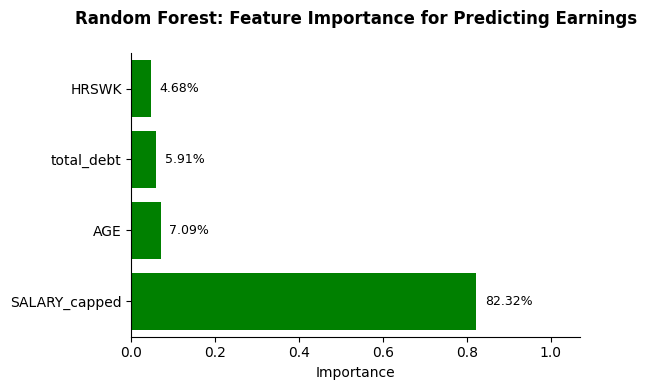


5-Fold Cross-Validation R2: 0.690 (+/- 0.061)

5.2 RANDOM FOREST CLASSIFIER: Predicting STEM Retention
All STEM graduates: 44,425

Class distribution:
working_in_stem_field
True     37839
False     6586
Name: count, dtype: int64
Records after dropping missing: 44,425
Stayers: 37,839, Leavers: 6,586

Training set: 35,540, Test set: 8,885
Training class balance: {1: 30271, 0: 5269}

Model Performance:
  Accuracy: 0.876

Classification Report:
              precision    recall  f1-score   support

     Leavers       0.65      0.37      0.47      1317
     Stayers       0.90      0.97      0.93      7568

    accuracy                           0.88      8885
   macro avg       0.77      0.67      0.70      8885
weighted avg       0.86      0.88      0.86      8885


Feature Importance:
  EARN: 0.378
  HRSWK: 0.280
  AGE: 0.216
  total_debt: 0.126


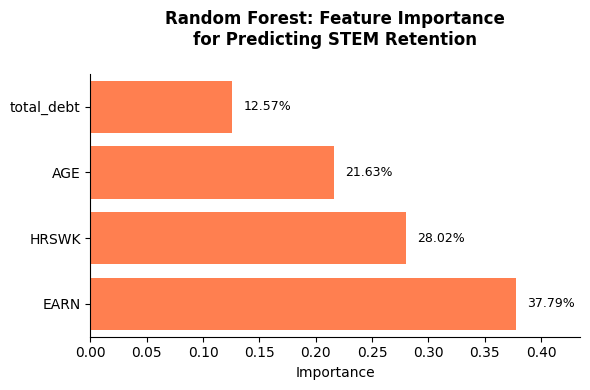


5-Fold Cross-Validation Accuracy: 0.871 (+/- 0.017)

5.3 HYPERPARAMETER TUNING
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.883


In [ ]:
# ============================================
# PART 5: RANDOM FOREST ANALYSIS (Week 11)
# ============================================

print("\n" + "="*70)
print("PART 5: RANDOM FOREST ANALYSIS (Week 11)")
print("="*70)

# 5.1 RANDOM FOREST REGRESSOR (Predict Earnings)

print("\n5.1 RANDOM FOREST REGRESSOR: Predicting Earnings")

# Use STEM graduates from recent data
stem_recent = df_recent[df_recent['is_stem_major'] == 1].copy()
print(f"STEM graduates for regression: {len(stem_recent):,}")

# Prepare data (Features: AGE, Hours Work, Total Debt, SALARY; Target: EARNINGS)
reg_features = ['AGE', 'HRSWK', 'total_debt', 'SALARY_capped']
reg_target = 'EARN'

reg_data = stem_recent[reg_features + [reg_target]].dropna()
print(f"Records after dropping missing: {len(reg_data):,}")

if len(reg_data) >= 100:
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        reg_data[reg_features], reg_data[reg_target],
        test_size=0.2, random_state=42
    )
    print(f"Training set: {len(X_train):,}, Test set: {len(X_test):,}")
    
    # Train model
    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_reg.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = rf_reg.predict(X_test)
    print(f"\nModel Performance:")
    print(f"  R2 Score: {r2_score(y_test, y_pred):.3f}")
    print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
    
    # Feature importance
    feat_imp = pd.DataFrame({
        'feature': reg_features,
        'importance': rf_reg.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nFeature Importance:")
    for _, row in feat_imp.iterrows():
        print(f"  {row['feature']}: {row['importance']:.3f}")
    
    # Plot with value labels
    plt.figure(figsize=(6, 4))
    bars = plt.barh(feat_imp['feature'], feat_imp['importance'], color='green')
    plt.xlabel('Importance')
    plt.title('Random Forest: Feature Importance for Predicting Earnings\n', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Add value labels on each bar
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{100 * width:.2f}%', ha='left', va='center', fontsize=9)
 
    # Set y-axis limits
    plt.xlim(0, feat_imp['importance'].max() * 1.3)
    plt.ylim(-0.5, len(feat_imp)-0.5)

    # Clean up spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    
    # Cross-validation
    cv_scores = cross_val_score(rf_reg, reg_data[reg_features], reg_data[reg_target], 
                                 cv=5, scoring='r2')
    print(f"\n5-Fold Cross-Validation R2: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

else:
    print(f"Not enough records (Need at least 100), have {len(reg_data)}")


# 5.2 RANDOM FOREST CLASSIFIER (Predict STEM Retention)

print("\n5.2 RANDOM FOREST CLASSIFIER: Predicting STEM Retention")

# Use ALL STEM graduates from df_final
stem_all = df_final[df_final['is_stem_major'] == 1].copy()
print(f"All STEM graduates: {len(stem_all):,}")

# Check class distribution
print(f"\nClass distribution:")
print(stem_all['working_in_stem_field'].value_counts())

# Prepare data
class_features = ['AGE', 'EARN', 'total_debt', 'HRSWK']
class_target = 'working_in_stem_field'

class_data = stem_all[class_features + [class_target]].dropna()
print(f"Records after dropping missing: {len(class_data):,}")

# Check class balance
leaver_count = (class_data[class_target] == False).sum()
stayer_count = (class_data[class_target] == True).sum()
print(f"Stayers: {stayer_count:,}, Leavers: {leaver_count:,}")

if leaver_count >= 30 and stayer_count >= 30:
    # Convert to int
    class_data[class_target] = class_data[class_target].astype(int)
    
    # Split with stratification to maintain class balance
    X_train, X_test, y_train, y_test = train_test_split(
        class_data[class_features], class_data[class_target],
        test_size=0.2, random_state=42, stratify=class_data[class_target]
    )
    
    print(f"\nTraining set: {len(X_train):,}, Test set: {len(X_test):,}")
    print(f"Training class balance: {y_train.value_counts().to_dict()}")
    
    # Train with class_weight to handle imbalance
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_clf.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = rf_clf.predict(X_test)
    print(f"\nModel Performance:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Leavers', 'Stayers']))
    
    # Feature importance
    feat_imp_clf = pd.DataFrame({
        'feature': class_features,
        'importance': rf_clf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nFeature Importance:")
    for _, row in feat_imp_clf.iterrows():
        print(f"  {row['feature']}: {row['importance']:.3f}")
    
    # Classifier feature importance with value labels
    plt.figure(figsize=(6, 4))
    bars = plt.barh(feat_imp_clf['feature'], feat_imp_clf['importance'], color='coral')
    plt.xlabel('Importance')
    plt.title('Random Forest: Feature Importance\nfor Predicting STEM Retention\n', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()

    # Add value labels on each bar
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{100 * width:.2f}%', ha='left', va='center', fontsize=9)
        
    # Set y-axis limits
    plt.xlim(0, feat_imp_clf['importance'].max()*1.15)
    plt.ylim(-0.5, len(feat_imp_clf)-0.5)

    # Clean up spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Cross-validation
    cv_scores = cross_val_score(rf_clf, class_data[class_features], class_data[class_target], 
                                 cv=5, scoring='accuracy')
    print(f"\n5-Fold Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    
    # Hyperparameter tuning
    print("\n5.3 HYPERPARAMETER TUNING")
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        param_grid, cv=3, scoring='accuracy', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Accuracy: {grid_search.best_score_:.3f}")
    
else:
    print(f"Not enough records (Need at least 30 stayers and 30 leavers)")
    print(f"Have {leaver_count} leavers and {stayer_count} stayers.")

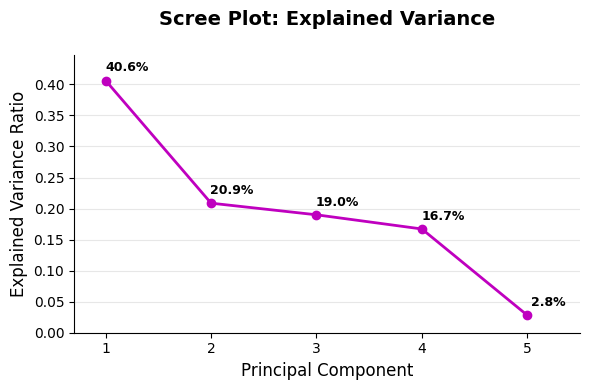

In [ ]:
# Scree plot for Milestone 4 graph

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_, 'mo-', linewidth=2, markersize=6)

# Add data point labels for each dot
for i, var in enumerate(pca.explained_variance_ratio_):
    plt.text(i+1.2, var + 0.01, f'{var*100:.1f}%', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set ticks to be integers corresponding to component numbers
num_components = len(pca.explained_variance_ratio_)
plt.xticks(range(1, num_components + 1, 1))

# Labels and grid
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Scree Plot: Explained Variance\n', fontsize=14, fontweight='bold')
plt.grid(which='major', axis='y', alpha=0.3)
plt.xlim(0.7, num_components + 0.5)
plt.ylim(0, max(pca.explained_variance_ratio_)*1.1)

plt.tight_layout()
plt.show()


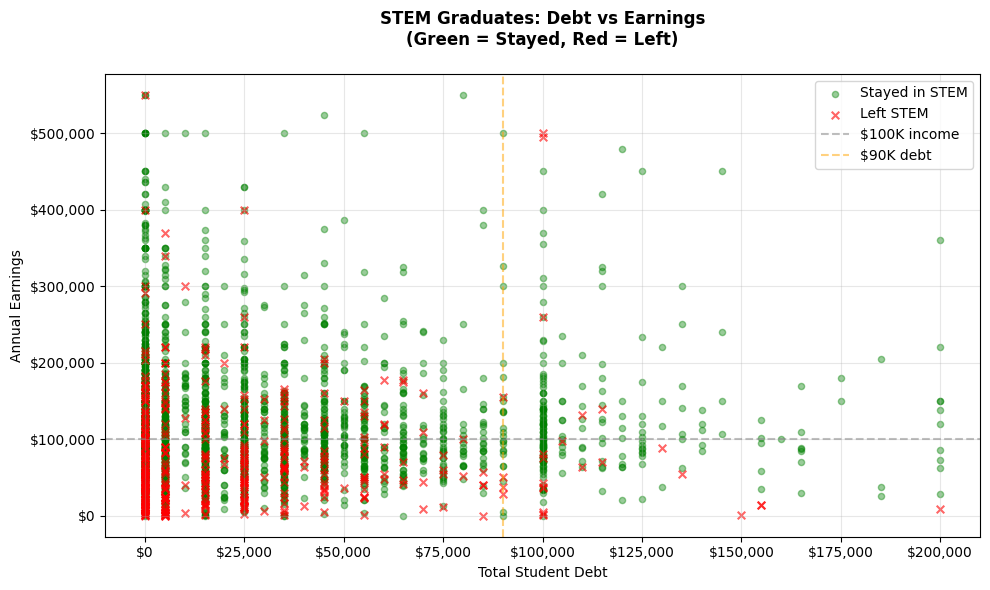

In [ ]:
# Scatter plot for Milestone 4 graph

# Prepare data
plot_data = df_final[df_final['is_stem_major'] == 1].copy()
plot_data = plot_data.dropna(subset=['total_debt', 'EARN', 'working_in_stem_field'])

# Sample for cleaner visualization 
sample_data = plot_data.sample(min(3000, len(plot_data)), random_state=42)

# Create figure
plt.figure(figsize=(10, 6))

# Plot stayers (green) and leavers (red)
stayers = sample_data[sample_data['working_in_stem_field'] == True]
leavers = sample_data[sample_data['working_in_stem_field'] == False]

plt.scatter(stayers['total_debt'], stayers['EARN'], 
            alpha=0.4, s=20, c='green', label='Stayed in STEM')
plt.scatter(leavers['total_debt'], leavers['EARN'], 
            alpha=0.6, s=30, c='red', label='Left STEM', marker='x')

# Add reference lines
plt.axhline(y=100000, color='gray', linestyle='--', alpha=0.5, label='$100K income')
plt.axvline(x=90000, color='orange', linestyle='--', alpha=0.5, label='$90K debt')

# Labels and title
plt.xlabel('Total Student Debt')
plt.ylabel('Annual Earnings')
plt.title('STEM Graduates: Debt vs Earnings\n(Green = Stayed, Red = Left)\n', fontsize=12, fontweight='bold')

# Format axes as currency
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

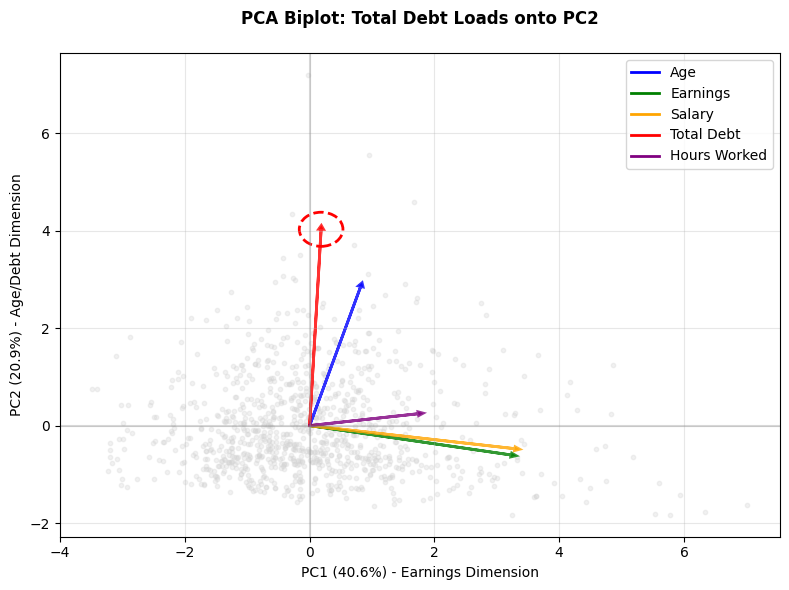

In [ ]:
# PCA Biplot for Milestone 4 graph

# Prepare data
pca_features = ['AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK']
pca_data = df_recent[pca_features].dropna()

# Standardize and fit PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create biplot
plt.figure(figsize=(8, 6))

# Sample points for clarity
sample_idx = np.random.choice(len(pca_result), size=min(1000, len(pca_result)), replace=False)
plt.scatter(pca_result[sample_idx, 0], pca_result[sample_idx, 1], 
            alpha=0.3, s=10, c='lightgray')

# Scale factor for arrows
scale = 5

# Colors for each variable
colors = {'AGE': 'blue', 'EARN': 'green', 'SALARY_capped': 'orange', 
          'total_debt': 'red', 'HRSWK': 'purple'}

# Plot arrows for all variables (without text labels)
for i, feature in enumerate(pca_features):
    color = colors.get(feature, 'black')
    x_end = pca.components_[0, i] * scale
    y_end = pca.components_[1, i] * scale
    
    plt.arrow(0, 0, x_end, y_end,
              head_width=0.08, head_length=0.08, fc=color, ec=color, alpha=0.8, linewidth=2)

# Add reference lines
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

# Labels and title
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) - Earnings Dimension')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) - Age/Debt Dimension')
plt.title('PCA Biplot: Total Debt Loads onto PC2\n',
          fontsize=12, fontweight='bold')

# Add a subtle circle around total_debt arrow to highlight it
debt_idx = pca_features.index('total_debt')
x_debt = pca.components_[0, debt_idx] * scale
y_debt = pca.components_[1, debt_idx] * scale
circle = plt.Circle((x_debt, y_debt), 0.35, color='red', fill=False, linewidth=2, linestyle='--')
plt.gca().add_patch(circle)

plt.legend([plt.Line2D([0], [0], color='blue', lw=2),
            plt.Line2D([0], [0], color='green', lw=2),
            plt.Line2D([0], [0], color='orange', lw=2),
            plt.Line2D([0], [0], color='red', lw=2),
            plt.Line2D([0], [0], color='purple', lw=2)],
           ['Age', 'Earnings', 'Salary', 'Total Debt', 'Hours Worked'],
           loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()